In [19]:
import steps.preprocess as preproc
import steps.edge_detector as edge_detector
import steps.edge_closer as edge_closer
import steps.region_segmentor as region_segmentor
import steps.color_quantizer as color_quantizer
import steps.background_removal as bg_removal
import steps.extract_features as extract_features
import steps.recolorize as recolorize
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [20]:
SEED = 42
np.random.seed(SEED)
cv2.setRNGSeed(SEED)
COLORS = 10

In [21]:
def plot(img, title=None, color=False):
    if color:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

Step 1: Preprocessing


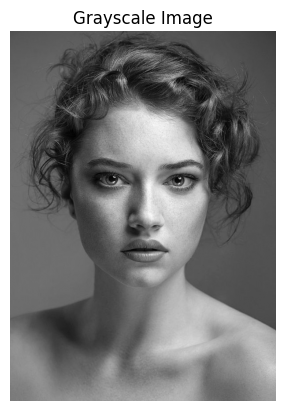

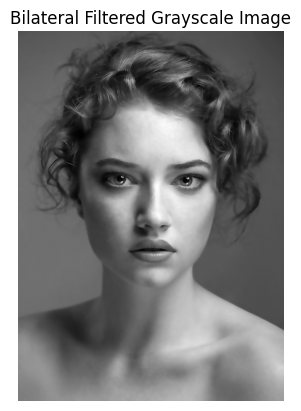

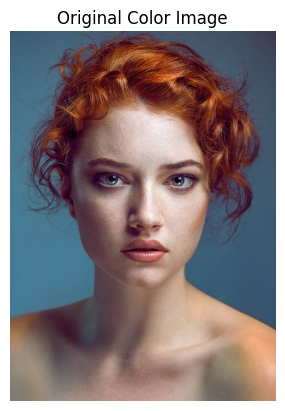

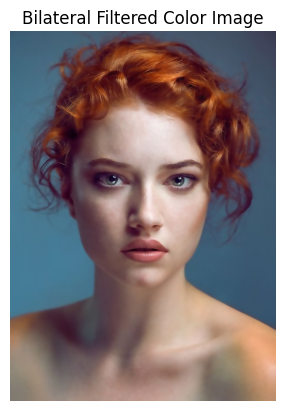

In [22]:
# Step 1: Preprocess image 
image = 'sample_images/portrait1.jpg'
print("Step 1: Preprocessing")
img, gray_img, bf_img, bf_gray = preproc.preprocess(image)

plot(gray_img, "Grayscale Image")
plot(bf_gray, "Bilateral Filtered Grayscale Image")
plot(img, "Original Color Image", color=True)
plot(bf_img, "Bilateral Filtered Color Image", color=True)

Step 1.5: Removing background


I0000 00:00:1780021176.038275 2996979 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M2
W0000 00:00:1780021176.040903 2996983 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


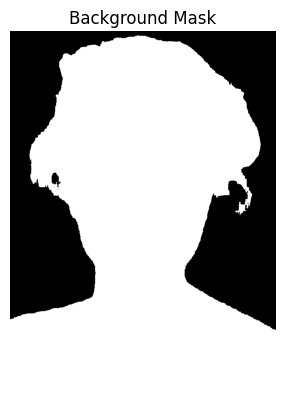

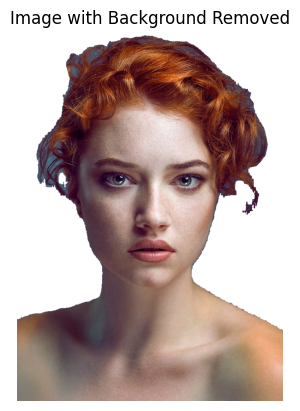

In [23]:
# Step 1.5: Remove Background
print("Step 1.5: Removing background")
img_no_bg, bg_mask = bg_removal.remove_background(img, background_color=(255, 255, 255))

plot(bg_mask, "Background Mask")
plot(img_no_bg, "Image with Background Removed", color=True)

img = img_no_bg
bf_img = cv2.bilateralFilter(img_no_bg, 9, 75, 75)

Step 2: Quantizing colors


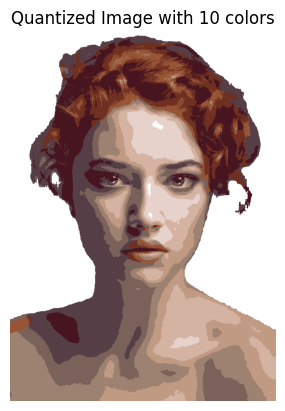

In [24]:
# Step 2: Color Quantization - k-means on smoothed bf_img to avoid dither noise
print("Step 2: Quantizing colors")
quantized = color_quantizer.quantize_colors(bf_img, k=COLORS)

plot(quantized, f"Quantized Image with {COLORS} colors", color=True)

Step 3: Detecting edges and color boundaries


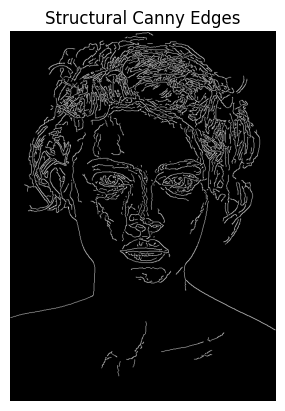

In [25]:
# Step 3: Edge Detection - structural canny + k-means color boundaries
print("Step 3: Detecting edges and color boundaries")
structural_edges = edge_detector.canny_edge_detector(bf_gray, percentageOfNonEdge=0.85)

plot(structural_edges, "Structural Canny Edges")

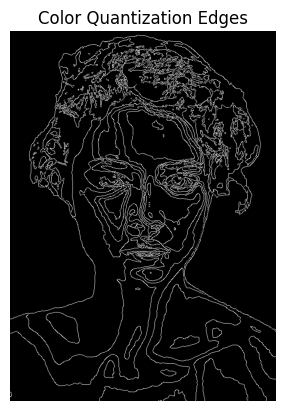

In [26]:
# Extract clean boundaries from the flat quantized color blocks
quantized_gray = cv2.cvtColor(quantized, cv2.COLOR_BGR2GRAY)
color_edges = cv2.Canny(quantized_gray, 10, 100)

plot(color_edges, "Color Quantization Edges")

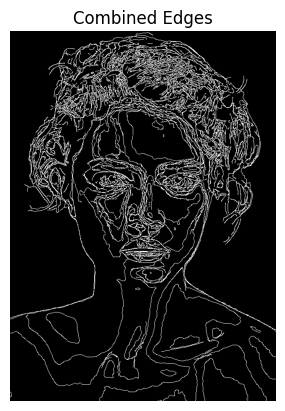

In [27]:
# Combine structural outlines with color-delineated boundaries 
combined_edges = cv2.bitwise_or(structural_edges, color_edges)

plot(combined_edges, "Combined Edges")

Extracting facial features for selective filtering...
Successfully extracted eye and lips masks


W0000 00:00:1780021178.227395 2997006 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1780021178.238215 2997006 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M2
W0000 00:00:1780021178.239910 2997009 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780021178.257340 2997012 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


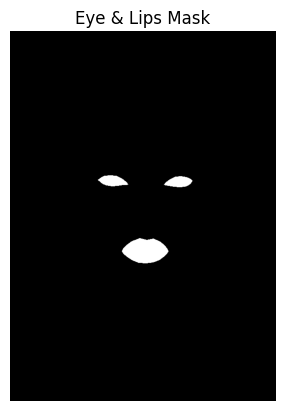

In [28]:
# Extract eye and lips feature masks using facial landmarks
print("Extracting facial features for selective filtering...")

feature_mask = extract_features.create_feature_mask(img)

plot(feature_mask, "Eye & Lips Mask")

Filtering dense edges (preserving eyes & lips)...


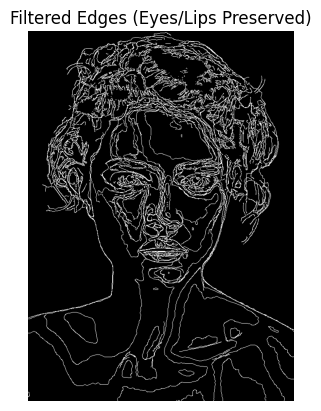

In [29]:
# Remove dense edges in hair/background while preserving fine edges in eyes/lips
print("Filtering dense edges (preserving eyes & lips)...")
filtered_edges = edge_closer.remove_dense_regions_selective(
    combined_edges, 
    preserve_mask=feature_mask,
    window_size=25, 
    density_thresh=0.35
)
plot(filtered_edges, "Filtered Edges (Eyes/Lips Preserved)")
combined_edges = filtered_edges

Step 4: Closing edge gaps


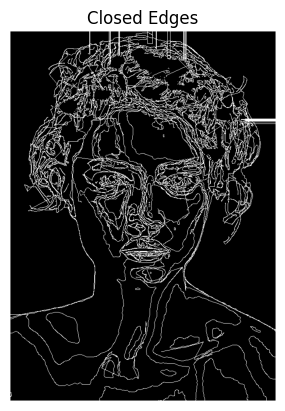

In [30]:
# Step 4: Close Edge Gaps - iterative endpoint stitching + border sealing
print("Step 4: Closing edge gaps")
closed = edge_closer.close_edges(combined_edges)

plot(closed, "Closed Edges")

Step 5: Segmenting regions


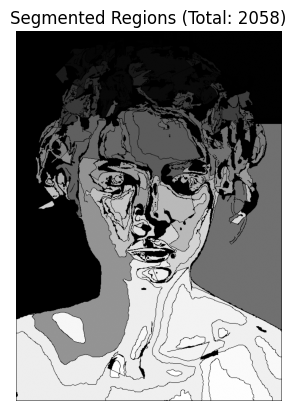

In [31]:
# Step 5: Region Segmentation - connected components
print("Step 5: Segmenting regions")
labels, num_labels = region_segmentor.segment_regions(closed, min_area=200)

plot(labels, f"Segmented Regions (Total: {num_labels})")

Step 6: Colorizing regions


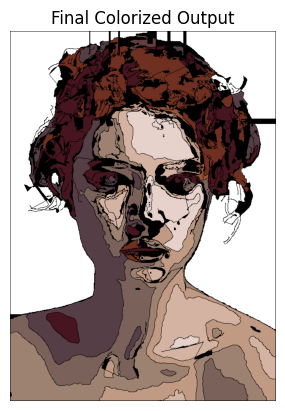

In [32]:
# Step 6: Colorize Regions - median quantized color per region
print("Step 6: Colorizing regions")
output = color_quantizer.colorize_regions(img, labels, num_labels, quantized)

plot(output, "Final Colorized Output", color=True)

Step 7: Overlaying edges


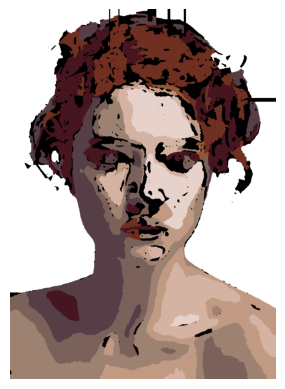

In [33]:
# Step 7: Overlay Edges
print("Step 7: Overlaying edges")
result = color_quantizer.overlay_edges(output, closed)

plot(result, color=True)

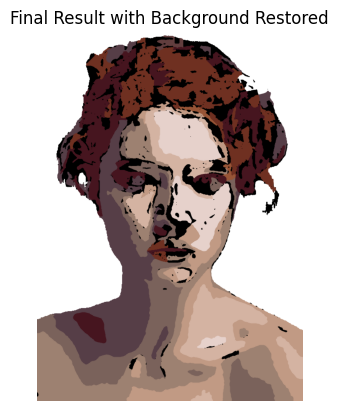

In [34]:
# Step 7.5: Reapply background mask
result_bg = result.copy()
result_bg[bg_mask == 0] = (255, 255, 255)  # Set background pixels to white
plot(result_bg, "Final Result with Background Restored", color=True)

In [35]:
BLUE_PALETTE = [
    "#03045e",
    "#023e8a",
    "#0077b6",
    "#0096c7",
    "#00b4d8",
    "#48cae4",
    "#ade8f4",
    "#caf0f8",
]

GREEN_PALETTE = [
    "#DAD7CD",
    "#A3B18A",
    "#7E9971",
    "#588157",
    "#3A5A40",
    "#344E41",
    "#273930",
    "#1A231F",
]

RED_PALETTE = [
    "#161a1d",
    "#660708",
    "#a4161a",
    "#ba181b",
    "#e5383b",
    "#b1a7a6",
    "#d3d3d3",
    "#f5f3f4",
]

BOLD_BERRY_PALETTE = [
    "#FAF5F0",
    "#FAE8D7",
    "#F9DBBD",
    "#FFA5AB",
    "#DA627D",
    "#A53860",
    "#752140",
    "#752140",
]

OCEAN_SUNSET_PALETTE = ["#001219","#005f73","#0a9396","#94d2bd","#e9d8a6","#ee9b00","#ca6702","#bb3e03","#ae2012","#9b2226"]

GRADIENT_BLUES_PALETTE = ["#6930c3","#5e60ce","#5390d9","#4ea8de","#48bfe3","#56cfe1","#64dfdf","#72efdd","#80ffdb"]

VIBRANT_PALETTE = ["#f94144","#f3722c","#f8961e","#f9844a","#f9c74f","#90be6d","#43aa8b","#4d908e","#577590","#277da1"]

MEADOW_PALETTE = ["#d9ed92","#b5e48c","#99d98c","#76c893","#52b69a","#34a0a4","#168aad","#1a759f","#1e6091","#184e77"]

PINK_PALETTE = ["#ff0a54","#ff477e","#ff5c8a","#ff7096","#ff85a1","#ff99ac","#fbb1bd","#f9bec7","#f7cad0","#fae0e4"]

ORANGE_PALETTE = ["521903","782906","9d3908","d35a0a","e89743","fdd37c","fddf9a","fef6d7"]

Step 8: Remapping colors to palette


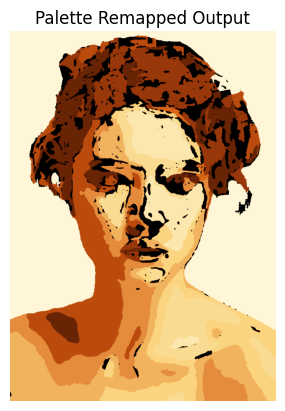

In [36]:
# Step 8: Palette remap by brightness rank
print("Step 8: Remapping colors to palette")

palette_result, sampled_colors, mapped_palette = recolorize.remap_to_palette_by_rank(
    result_bg,
    ORANGE_PALETTE,
)

plot(palette_result, "Palette Remapped Output", color=True)

In [37]:
# Save and display
image_name = os.path.splitext(os.path.basename(image))[0]
output_path = f"outputs/{image_name}_colorblock_orange.png"
cv2.imwrite(output_path, palette_result)

True